In [1]:
import pandas as pd
import io
import zipfile
from google.colab import files

print("Vui lòng bấm 'Choose Files' để tải file dataset.zip lên:")
uploaded = files.upload()

# Lấy tên file zip vừa upload
filename = list(uploaded.keys())[0]

# Mở file zip và đọc file .csv bên trong mà không cần giải nén ra ổ cứng
with zipfile.ZipFile(io.BytesIO(uploaded[filename]), 'r') as z:
    # Tìm tên file .csv có bên trong file zip
    csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]

    # Đọc file .csv đó bằng pandas
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

print(f"\nĐã tải và giải nén thành công file chứa trong '{filename}'!")
print("Xem trước 3 dòng đầu tiên:")
display(df.head(3))

Vui lòng bấm 'Choose Files' để tải file dataset.zip lên:


Saving archive.zip to archive.zip

Đã tải và giải nén thành công file chứa trong 'archive.zip'!
Xem trước 3 dòng đầu tiên:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


Số lượng giá trị thiếu (NaN) ở các cột:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Đã xử lý xong dữ liệu thiếu! Đang vẽ 6 biểu đồ EDA


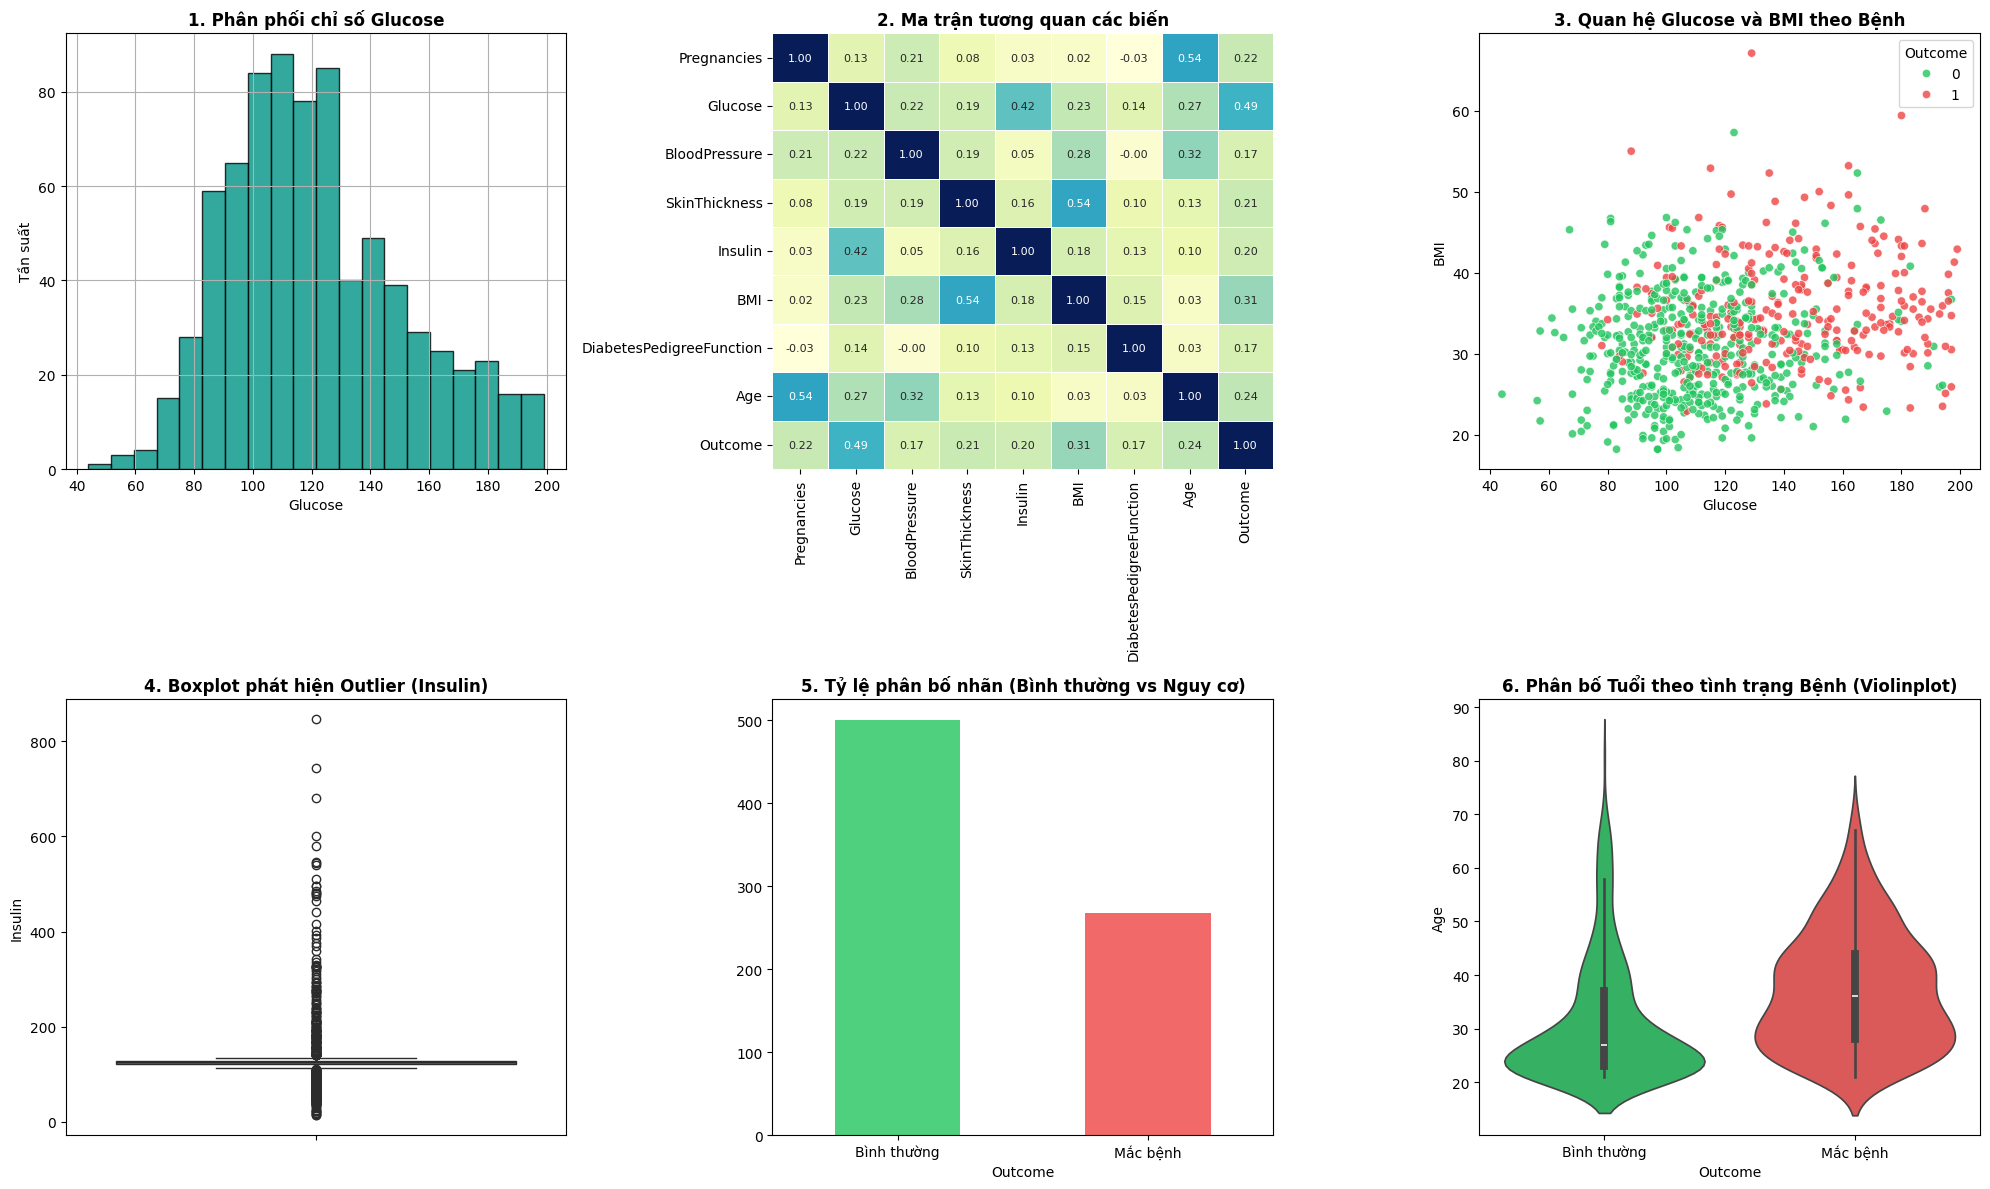

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thay thế các giá trị 0 vô lý thành NaN (trừ Pregnancies và Outcome)
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# Kiểm tra số lượng giá trị thiếu sau khi thay thế
print("Số lượng giá trị thiếu (NaN) ở các cột:")
print(df.isnull().sum())

# Điền giá trị thiếu (Imputation) bằng Median (Dùng cách gán trực tiếp để tránh FutureWarning của Pandas 3.0)
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

print("\nĐã xử lý xong dữ liệu thiếu! Đang vẽ 6 biểu đồ EDA")

# --- VẼ 6 HÌNH VẼ / BẢNG BIỂU CHO ĐỒ ÁN ---
plt.figure(figsize=(20, 12))

# Hình 1: Biểu đồ phân phối Histogram của chỉ số Glucose
plt.subplot(2, 3, 1)
df['Glucose'].hist(bins=20, color='#009485', edgecolor='black', alpha=0.8)
plt.title('1. Phân phối chỉ số Glucose', fontsize=12, fontweight='bold')
plt.xlabel('Glucose')
plt.ylabel('Tần suất')

# Hình 2: Ma trận tương quan Correlation Matrix Heatmap
plt.subplot(2, 3, 2)
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5, cbar=False, annot_kws={"size": 8})
plt.title('2. Ma trận tương quan các biến', fontsize=12, fontweight='bold')

# Hình 3: Biểu đồ Scatter phân tích quan hệ Glucose và BMI theo nhãn Outcome
plt.subplot(2, 3, 3)
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette=['#22c55e', '#ef4444'], alpha=0.8)
plt.title('3. Quan hệ Glucose và BMI theo Bệnh', fontsize=12, fontweight='bold')

# Hình 4: Biểu đồ Boxplot phát hiện Outliers của cột Insulin
plt.subplot(2, 3, 4)
sns.boxplot(y=df['Insulin'], color='#009485')
plt.title('4. Boxplot phát hiện Outlier (Insulin)', fontsize=12, fontweight='bold')

# Hình 5: Biểu đồ tỷ lệ mắc tiểu đường (Outcome)
plt.subplot(2, 3, 5)
df['Outcome'].value_counts().plot(kind='bar', color=['#22c55e', '#ef4444'], rot=0, alpha=0.8)
plt.title('5. Tỷ lệ phân bố nhãn (Bình thường vs Nguy cơ)', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Bình thường', 'Mắc bệnh'])

# Hình 6: Biểu đồ Violinplot so sánh độ tuổi (Age) theo tình trạng bệnh (đã sửa chuẩn seaborn mới)
plt.subplot(2, 3, 6)
sns.violinplot(x='Outcome', y='Age', hue='Outcome', data=df, palette=['#22c55e', '#ef4444'], legend=False)
plt.title('6. Phân bố Tuổi theo tình trạng Bệnh (Violinplot)', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Bình thường', 'Mắc bệnh'])

plt.tight_layout()
plt.show()